<a href="https://colab.research.google.com/github/Victorpc132/ProjetosPythonRauber/blob/main/04_Modelo_ML_Flores_Iris_Colab%2BImplanta%C3%A7%C3%A3o_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Modelo de ML End-to-End — **Dataset de Flores (Iris)**
Professor: *Use este notebook como roteiro didático*. Ele está organizado nas etapas clássicas de um projeto de Machine Learning, incluindo descrições e células de código.



## Sumário das Etapas
1. **Definição do Problema e Métricas**  
2. **Coleta e Entendimento dos Dados**  
3. **Pré-processamento e Limpeza**  
4. **Análise Exploratória (EDA)**  
5. **Engenharia de Atributos**  
6. **Divisão dos Dados (Train/Validation/Test)**  
7. **Modelagem (Modelos e Hiperparâmetros)**  
8. **Avaliação**  
9. **Otimização e Regularização**  
10. **Exportação/Serviço do Modelo (Deployment demo)**  
11. **Monitoramento (conceitos)**  



## 0. Preparação do Ambiente
Instale/importe bibliotecas necessárias. No Google Colab, muitas já vêm instaladas.


In [ ]:

# Se necessário, descomente linhas de instalação
# !pip install scikit-learn matplotlib pandas numpy joblib fastapi "uvicorn[standard]" --quiet

import sys, platform, sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Python:", sys.version.split()[0])
print("SO:", platform.platform())
print("scikit-learn:", sklearn.__version__)


Python: 3.13.16
SO: Linux-6.6.122+-x86_64-with-glibc2.39
scikit-learn: 1.6.1



## 1. Definição do Problema e Métricas
**Objetivo:** Classificar a espécie de uma flor com base em medidas do cálice (**sepal**) e da pétala (**petal**).  
**Entrada (features):** comprimentos e larguras de sépalas e pétalas.  
**Saída (target):** espécie (setosa, versicolor, virginica).

**Métricas:** Para classificação multiclasse, usaremos **accuracy** e **F1-macro**.  
**Critério de sucesso (exemplo didático):** `accuracy ≥ 0.95` no conjunto de teste.



## 2. Coleta e Entendimento dos Dados
Usaremos o **dataset Iris** (gratuito), disponível no `scikit-learn`.  
Essa etapa, em projetos reais, envolveria APIs, bancos, sensores etc.


In [ ]:

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width',
    'target': 'species_id'
}, inplace=True)

# Mapeia id -> nome da espécie
target_names = dict(enumerate(iris.target_names))
df['species'] = df['species_id'].map(target_names)

print("Dimensão do dataset:", df.shape)
df.head()


Dimensão do dataset: (150, 6)


,sepal_length,sepal_width,petal_length,petal_width,species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



## 3. Pré-processamento e Limpeza
- Verificar **valores ausentes** e **outliers**.  
- Separar **features** e **target**.  
- Padronizar atributos numéricos (quando o algoritmo for sensível à escala).


In [ ]:

# Checagem de valores ausentes
print(df.isna().sum())

# Estatísticas descritivas
display(df.describe())

# Define X (features) e y (target)
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[feature_cols].values
y = df['species'].values
print("X shape:", X.shape, "| y shape:", y.shape)


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species_id      0
species         0
dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


X shape: (150, 4) | y shape: (150,)



## 4. Análise Exploratória (EDA)
- Visualize distribuições e relações entre atributos.  
- Em projetos maiores, use gráficos interativos; aqui manteremos o essencial com `matplotlib`.


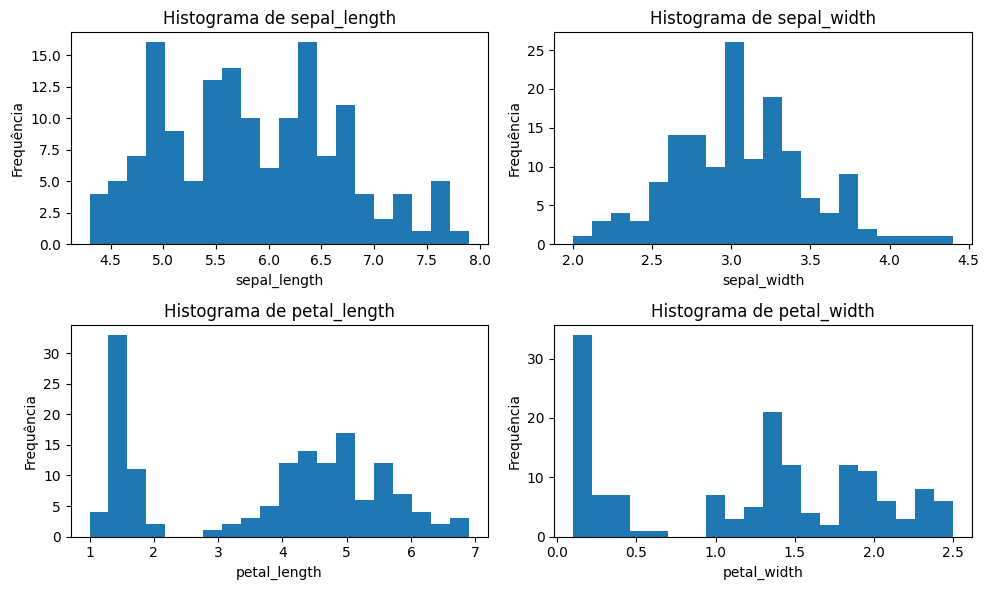

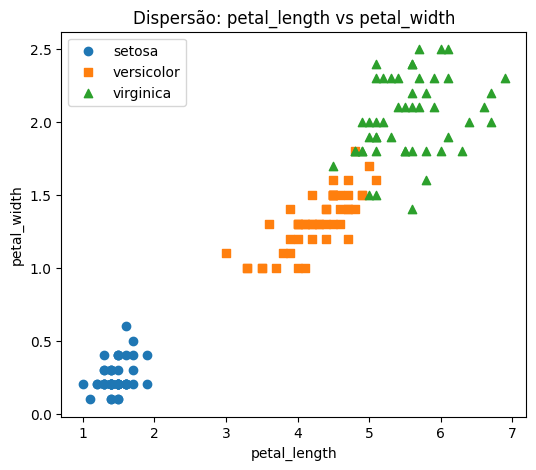

In [ ]:

# Histogramas simples por feature
import math

n = X.shape[1]
cols = 2
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(10, 6))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].values, bins=20)
    axes[i].set_title(f"Histograma de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

# Esconde eixos não usados
for j in range(i+1, rows*cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Scatter simples: petal_length vs petal_width colorindo por espécie
species_unique = df['species'].unique()
markers = ['o', 's', '^']

plt.figure(figsize=(6, 5))
for idx, sp in enumerate(species_unique):
    subset = df[df['species'] == sp]
    plt.scatter(subset['petal_length'], subset['petal_width'], marker=markers[idx], label=sp)
plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.title("Dispersão: petal_length vs petal_width")
plt.legend()
plt.show()



## 5. Engenharia de Atributos
- Criar atributos derivados simples (ex.: **razões** e **áreas aproximadas**).  
- **Atenção:** Evite usar atributos que vazem informação do futuro (data leakage).


In [ ]:

# Exemplo de features derivadas
df['sepal_area'] = df['sepal_length'] * df['sepal_width']
df['petal_area'] = df['petal_length'] * df['petal_width']

feature_cols_ext = feature_cols + ['sepal_area', 'petal_area']
X_ext = df[feature_cols_ext].values
y = df['species'].values

print("Novas features:", feature_cols_ext)
print("X_ext shape:", X_ext.shape)


Novas features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'sepal_area', 'petal_area']
X_ext shape: (150, 6)



## 6. Divisão dos Dados
Dividiremos em **treino** e **teste**, estratificando por espécie, e usaremos **validação cruzada** durante a modelagem.


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ext, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (120, 6) | Teste: (30, 6)



## 7. Modelagem (Modelos e Hiperparâmetros)
Vamos treinar três modelos clássicos e comparar:
- **Regressão Logística**
- **SVM** (RBF)
- **Random Forest**

Usaremos `Pipeline` + `StandardScaler` quando necessário e **GridSearchCV** para ajuste de hiperparâmetros.


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "logreg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=200))]),
    "svm": Pipeline([("scaler", StandardScaler()), ("clf", SVC())]),
    "rf": Pipeline([("clf", RandomForestClassifier(random_state=42))])
}

param_grids = {
    "logreg": {"clf__C": [0.1, 1.0, 10.0]},
    "svm": {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.1, 0.01]},
    "rf": {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 3, 5]}
}

results = {}
best_estimators = {}

for name, pipe in pipelines.items():
    gs = GridSearchCV(pipe, param_grids[name], cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    y_pred = gs.predict(X_test)
    results[name] = {
        "best_params": gs.best_params_,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    }

pd.DataFrame(results).T


,best_params,accuracy,f1_macro
logreg,{'clf__C': 10.0},1.0,1.0
svm,"{'clf__C': 0.5, 'clf__gamma': 'scale'}",0.966667,0.966583
rf,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.933333,0.933333



## 8. Avaliação
- Relatório de classificação e matriz de confusão.  
- **Curvas de aprendizado** para checar viés/variância (didático).


Melhor modelo: logreg | params: {'clf__C': 10.0}

Relatório de Classificação:

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    1.0000    1.0000        10
   virginica     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30



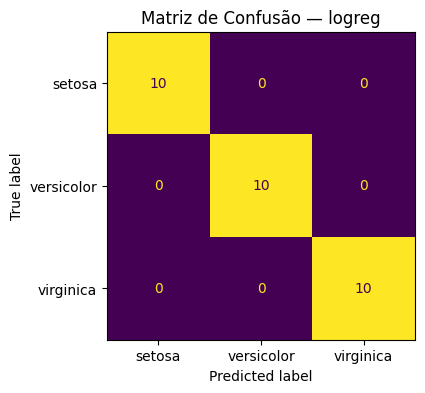

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Escolhe o melhor modelo por accuracy
best_name = max(results.keys(), key=lambda k: results[k]["accuracy"])
best_model = best_estimators[best_name]
print(f"Melhor modelo: {best_name} | params: {results[best_name]['best_params']}")

y_pred = best_model.predict(X_test)
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
plt.title(f"Matriz de Confusão — {best_name}")
plt.show()


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

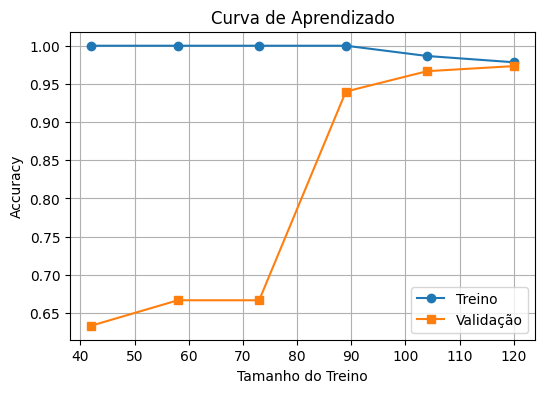

In [ ]:

from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    best_model, X_ext, y, cv=5, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, marker='o', label='Treino')
plt.plot(train_sizes, valid_mean, marker='s', label='Validação')
plt.xlabel("Tamanho do Treino")
plt.ylabel("Accuracy")
plt.title("Curva de Aprendizado")
plt.legend()
plt.grid(True)
plt.show()



## 9. Otimização e Regularização
- Ajuste fino de hiperparâmetros (já fizemos com `GridSearchCV`).  
- **Regularização**: `C` em Regressão Logística/SVM controla a penalização; `max_depth` e `n_estimators` em Random Forest controlam complexidade.  
- **Data augmentation**: comum em visão computacional (imagens).



## 10. Exportação/Serviço do Modelo (Deployment demo)
Nesta etapa:
1. **Salvamos** o melhor pipeline treinado (`joblib`).  
2. **Carregamos** e usamos para predizer.  
3. (Opcional) Mostramos um **mini-exemplo de API** com `FastAPI`.


In [ ]:

import joblib

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)
model_path = artifacts_dir / "best_model.joblib"
joblib.dump(best_model, model_path)

print("Modelo salvo em:", model_path.resolve())

# Carrega e testa
loaded = joblib.load(model_path)
sample = X_test[:3]
pred = loaded.predict(sample)
print("Predições de exemplo:", pred)


Modelo salvo em: /content/artifacts/best_model.joblib
Predições de exemplo: [np.str_('setosa') np.str_('virginica') np.str_('versicolor')]


In [ ]:

# --- Exemplo simples de API com FastAPI (opcional) ---
# Para rodar no Colab: remova os comentários, execute a célula e abra o link gerado pelo Uvicorn/ngrok (se configurado).
#
# from fastapi import FastAPI
# import uvicorn
# import joblib
# import numpy as np
#
# app = FastAPI(title="API Iris")
# model = joblib.load("artifacts/best_model.joblib")
# feature_cols = ['sepal_length','sepal_width','petal_length','petal_width','sepal_area','petal_area']
#
# @app.get("/ping")
# def ping():
#     return {"status": "ok"}
#
# @app.post("/predict")
# def predict(features: list):
#     X = np.array(features).reshape(1, -1)
#     y_pred = model.predict(X)[0]
#     return {"prediction": str(y_pred)}
#
# if __name__ == "__main__":
#     uvicorn.run(app, host="0.0.0.0", port=8000)



## 11. Monitoramento (conceitos)
- **Data/Concept Drift**: mudanças nos dados/relações ao longo do tempo degradam o desempenho.  
- **Métricas em produção**: acompanhe distribuições de entrada e acurácia (quando rótulos estiverem disponíveis).  
- **Ciclo de re-treino**: agende reavaliações periódicas, colete novos dados, re-treine e re-versione o modelo.



## Exercícios Propostos
1. Experimente remover as features derivadas e compare resultados.  
2. Troque a métrica de busca no `GridSearchCV` para `f1_macro`.  
3. Adicione **KNN** como quarto modelo.  
4. Gere gráficos adicionais (ex.: pairwise scatter) e interprete-os.


### Resolução do Exercício 1: Removendo Features Derivadas
Utilize a célula abaixo para realizar a divisão dos dados originais (sem as áreas de sépala e pétala), rodar o treinamento e comparar os resultados de acurácia.

### 📝 Exercício 1: Comparação de Modelos sem Features Derivadas

Nesta etapa, voltamos às **4 características originais** do dataset Iris (removendo as áreas calculadas) para treinar os modelos:
* **Regressão Logística**
* **SVM (RBF)**
* **Random Forest**

O objetivo é analisar o impacto da engenharia de atributos na performance de cada algoritmo utilizando a métrica simples de acurácia.

In [10]:
# Importações necessárias para garantir que tudo funcione de forma independente
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Carrega as variáveis X e y originais direto do dataset para evitar o erro de 'not defined'
iris_data = load_iris()
X = iris_data.data
y = iris_data.target_names[iris_data.target]

# 2. Configurações dos modelos que estavam na Etapa 7
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "logreg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=200))]),
    "svm": Pipeline([("scaler", StandardScaler()), ("clf", SVC())]),
    "rf": Pipeline([("clf", RandomForestClassifier(random_state=42))])
}

param_grids = {
    "logreg": {"clf__C": [0.1, 1.0, 10.0]},
    "svm": {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.1, 0.01]},
    "rf": {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 3, 5]}
}

# Passo 1: Fazer a divisão de treino e teste usando as features originais (X)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino Original:", X_train_orig.shape, "| Teste Original:", X_test_orig.shape)

# Passo 2: Treinar os modelos com os dados originais
results_orig = {}
for name, pipe in pipelines.items():
    # Usamos o mesmo GridSearchCV configurado anteriormente
    gs_orig = GridSearchCV(pipe, param_grids[name], cv=cv, scoring="accuracy", n_jobs=-1)

    # Ajustando o modelo com os dados corretos (terminando em 'orig')
    gs_orig.fit(X_train_orig, y_train_orig)

    # Fazendo as predições com o teste correto
    y_pred_orig = gs_orig.predict(X_test_orig)

    # Guardando os resultados de acurácia
    results_orig[name] = {
        "accuracy": accuracy_score(y_test_orig, y_pred_orig)
    }

# Passo 3: Visualizar os resultados e comparar
pd.DataFrame(results_orig).T

Treino Original: (120, 4) | Teste Original: (30, 4)


,accuracy
logreg,1.000000
svm,0.933333
rf,0.966667


### 📝 Exercício 2: Troca da Métrica de Busca no GridSearchCV para `f1_macro`

Nesta etapa, alteramos o parâmetro `scoring` do `GridSearchCV` de `"accuracy"` para `"f1_macro"` para os três modelos originais, buscando otimizar o equilíbrio entre Precisão e Revocação (Recall) em cada classe.

In [14]:
from sklearn.metrics import f1_score
import pandas as pd

# Rodando a busca de hiperparâmetros focando na métrica f1_macro
results_f1_macro = {}

for name, pipe in pipelines.items():
    # Configurando o GridSearchCV com scoring='f1_macro'
    gs_f1 = GridSearchCV(pipe, param_grids[name], cv=cv, scoring="f1_macro", n_jobs=-1)
    gs_f1.fit(X_train_orig, y_train_orig)
    y_pred_f1 = gs_f1.predict(X_test_orig)

    results_f1_macro[name] = {
        "best_params": gs_f1.best_params_,
        "accuracy": accuracy_score(y_test_orig, y_pred_f1),
        "f1_macro": f1_score(y_test_orig, y_pred_f1, average="macro")
    }

print("=== RESULTADOS DO EXERCÍCIO 2 (Métrica: F1-Macro) ===")
display(pd.DataFrame(results_f1_macro).T)

=== RESULTADOS DO EXERCÍCIO 2 (Métrica: F1-Macro) ===


,best_params,accuracy,f1_macro
logreg,{'clf__C': 10.0},1.0,1.0
svm,"{'clf__C': 0.5, 'clf__gamma': 0.1}",0.933333,0.933333
rf,"{'clf__max_depth': 3, 'clf__n_estimators': 100}",0.966667,0.966583


### 📝 Exercício 3: Adição do Modelo KNN (K-Nearest Neighbors)

Adicionamos o algoritmo **KNN** ao nosso pipeline. Como o KNN é baseado no cálculo de distâncias matemáticas, incluímos um passo de padronização (`StandardScaler`) antes do classificador.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

# Definindo o pipeline específico e a grade de parâmetros para o KNN
knn_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())])
knn_param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9],
    "clf__weights": ["uniform", "distance"]
}

# Executando a otimização com GridSearchCV usando F1-Macro
gs_knn = GridSearchCV(knn_pipeline, knn_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_knn.fit(X_train_orig, y_train_orig)
y_pred_knn = gs_knn.predict(X_test_orig)

# Coletando os resultados
results_knn = {
    "knn": {
        "best_params": gs_knn.best_params_,
        "accuracy": accuracy_score(y_test_orig, y_pred_knn),
        "f1_macro": f1_score(y_test_orig, y_pred_knn, average="macro")
    }
}

print("=== RESULTADOS DO EXERCÍCIO 3 (Modelo KNN) ===")
display(pd.DataFrame(results_knn).T)

=== RESULTADOS DO EXERCÍCIO 3 (Modelo KNN) ===


,best_params,accuracy,f1_macro
knn,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.933333,0.93266


### 📝 Exercícios 2 & 3: Nova Métrica (F1-Macro) e Adição do Modelo KNN

Aqui expandimos nosso pipeline com duas grandes modificações:
1. **Exercício 2:** Alteramos o critério de seleção do `GridSearchCV` para focar no **`f1_macro`**, garantindo uma otimização equilibrada para todas as três espécies de flores.
2. **Exercício 3:** Adicionamos o algoritmo **KNN (K-Nearest Neighbors)** como o nosso quarto modelo preditivo, configurando uma busca de parâmetros para o número de vizinhos (`n_neighbors`) e pesos.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
import pandas as pd

# --- EXERCÍCIO 2 & 3: Adicionar KNN e trocar métrica de busca para 'f1_macro' ---

# Adicionamos o KNN na lista de pipelines
pipelines_ext = {
    "logreg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=200))]),
    "svm": Pipeline([("scaler", StandardScaler()), ("clf", SVC())]),
    "rf": Pipeline([("clf", RandomForestClassifier(random_state=42))]),
    "knn": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]) # KNN precisa de escala!
}

# Adicionamos os hiperparâmetros que o GridSearch testará para o KNN
param_grids_ext = {
    "logreg": {"clf__C": [0.1, 1.0, 10.0]},
    "svm": {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.1, 0.01]},
    "rf": {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 3, 5]},
    "knn": {"clf__n_neighbors": [3, 5, 7, 9], "clf__weights": ["uniform", "distance"]}
}

results_f1 = {}

# Treinamos agora otimizando para 'f1_macro'
for name, pipe in pipelines_ext.items():
    # Trocamos scoring para 'f1_macro' conforme Exercício 2
    gs_f1 = GridSearchCV(pipe, param_grids_ext[name], cv=cv, scoring="f1_macro", n_jobs=-1)
    gs_f1.fit(X_train_orig, y_train_orig)
    y_pred_f1 = gs_f1.predict(X_test_orig)

    results_f1[name] = {
        "best_params": gs_f1.best_params_,
        "accuracy": accuracy_score(y_test_orig, y_pred_f1),
        "f1_macro": f1_score(y_test_orig, y_pred_f1, average="macro")
    }

print("=== RESULTADOS APÓS EXERCÍCIOS 2 & 3 ===")
display(pd.DataFrame(results_f1).T)

=== RESULTADOS APÓS EXERCÍCIOS 2 & 3 ===


,best_params,accuracy,f1_macro
logreg,{'clf__C': 10.0},1.0,1.0
svm,"{'clf__C': 0.5, 'clf__gamma': 0.1}",0.933333,0.933333
rf,"{'clf__max_depth': 3, 'clf__n_estimators': 100}",0.966667,0.966583
knn,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.933333,0.93266


### 📝 Exercício 4: Análise Visual com Pairwise Scatter Plot (Pairplot)

Geramos um gráfico de dispersão cruzada pareando todos os atributos originais do dataset.

**O que analisar:**
* Como a espécie *Setosa* se isola completamente das demais.
* A sutil zona de interseção entre *Versicolor* e *Virginica*, que explica os pequenos erros cometidos por algoritmos sensíveis a fronteiras lineares.

=== EXERCÍCIO 4: Pairwise Scatter Plot (Correlação dos Atributos Originais) ===


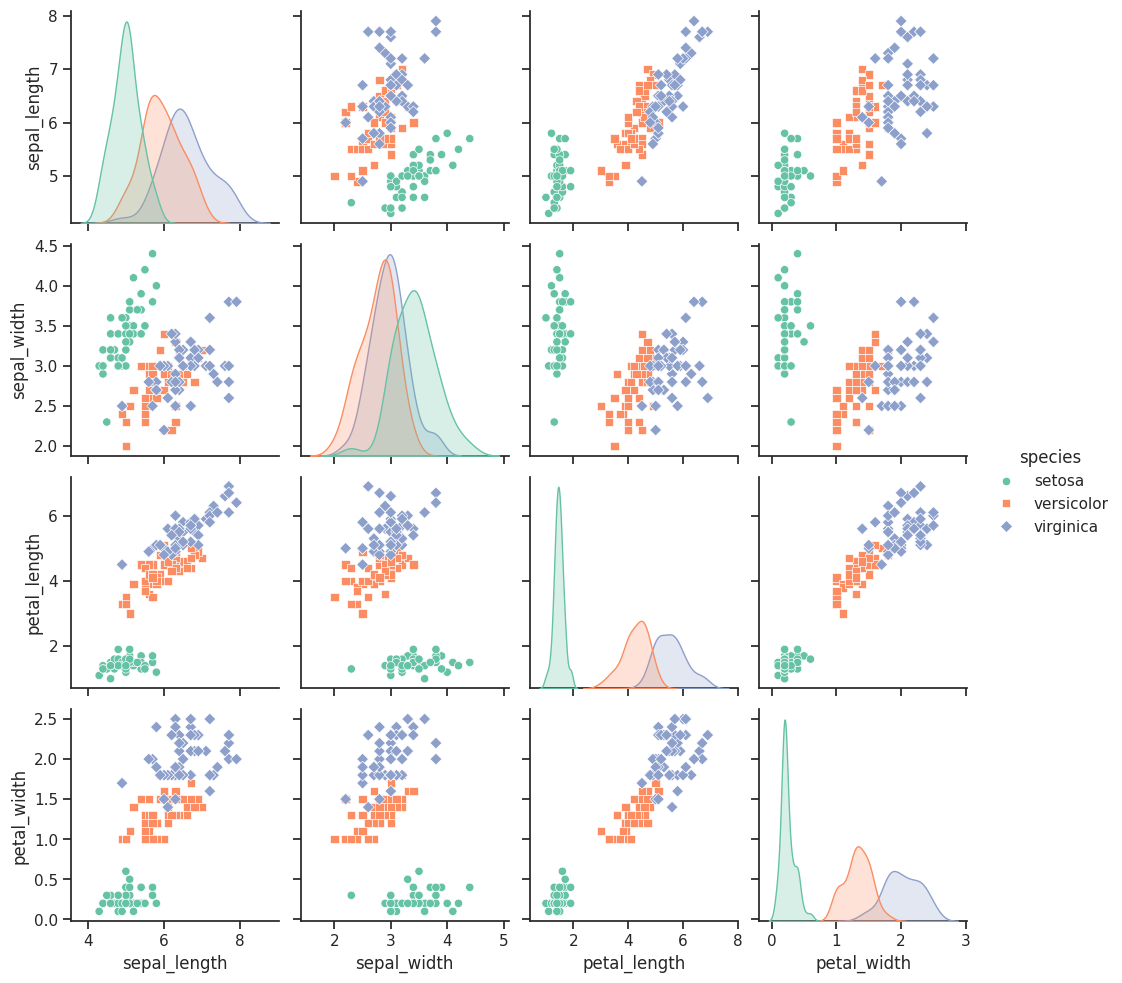

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- EXERCÍCIO 4: Gráfico Pairwise Scatter (Pairplot) ---
print("=== EXERCÍCIO 4: Pairwise Scatter Plot (Correlação dos Atributos Originais) ===")

# Criando um DataFrame temporário para facilitar o plot no Seaborn
df_plot = pd.DataFrame(X, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df_plot['species'] = y

# Plot pairwise
sns.set_theme(style="ticks")
sns.pairplot(df_plot, hue="species", markers=["o", "s", "D"], palette="Set2")
plt.show()

=== RESULTADOS APÓS EXERCÍCIOS 2 & 3 ===


,best_params,accuracy,f1_macro
logreg,{'clf__C': 10.0},1.0,1.0
svm,"{'clf__C': 0.5, 'clf__gamma': 0.1}",0.933333,0.933333
rf,"{'clf__max_depth': 3, 'clf__n_estimators': 100}",0.966667,0.966583
knn,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.933333,0.93266



=== EXERCÍCIO 4: Pairwise Scatter Plot (Correlação dos Atributos Originais) ===


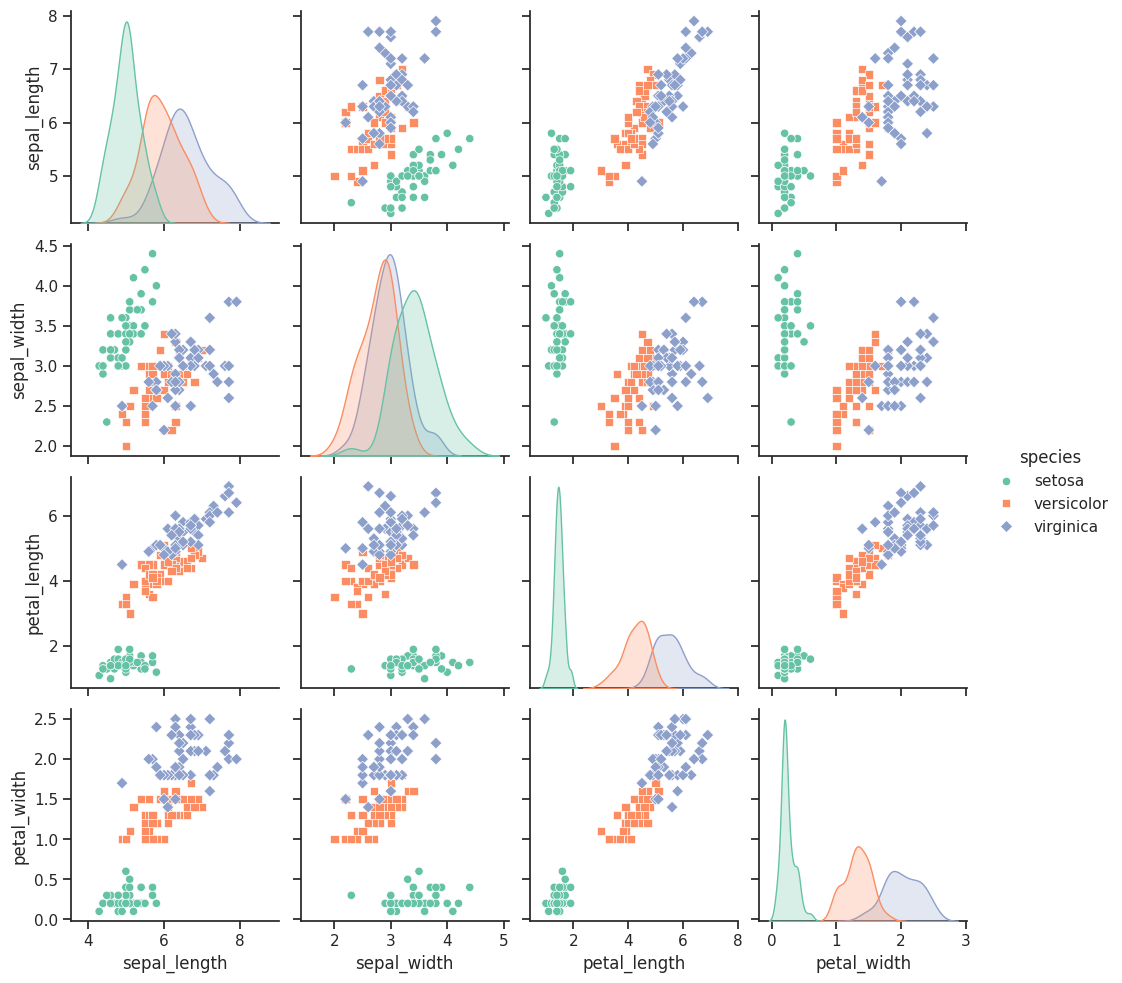

In [11]:
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# --- EXERCÍCIO 2 & 3: Adicionar KNN e trocar métrica de busca para 'f1_macro' ---

# Adicionamos o KNN na lista de pipelines
pipelines_ext = {
    "logreg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=200))]),
    "svm": Pipeline([("scaler", StandardScaler()), ("clf", SVC())]),
    "rf": Pipeline([("clf", RandomForestClassifier(random_state=42))]),
    "knn": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]) # KNN precisa de escala!
}

# Adicionamos os hiperparâmetros que o GridSearch testará para o KNN
param_grids_ext = {
    "logreg": {"clf__C": [0.1, 1.0, 10.0]},
    "svm": {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.1, 0.01]},
    "rf": {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 3, 5]},
    "knn": {"clf__n_neighbors": [3, 5, 7, 9], "clf__weights": ["uniform", "distance"]}
}

results_f1 = {}

# Treinamos agora otimizando para 'f1_macro'
for name, pipe in pipelines_ext.items():
    # Trocamos scoring para 'f1_macro' conforme Exercício 2
    gs_f1 = GridSearchCV(pipe, param_grids_ext[name], cv=cv, scoring="f1_macro", n_jobs=-1)
    gs_f1.fit(X_train_orig, y_train_orig)
    y_pred_f1 = gs_f1.predict(X_test_orig)

    results_f1[name] = {
        "best_params": gs_f1.best_params_,
        "accuracy": accuracy_score(y_test_orig, y_pred_f1),
        "f1_macro": f1_score(y_test_orig, y_pred_f1, average="macro")
    }

print("=== RESULTADOS APÓS EXERCÍCIOS 2 & 3 ===")
display(pd.DataFrame(results_f1).T)

# --- EXERCÍCIO 4: Gráfico Pairwise Scatter (Pairplot) ---
print("\n=== EXERCÍCIO 4: Pairwise Scatter Plot (Correlação dos Atributos Originais) ===")

# Criando um DataFrame temporário para facilitar o plot no Seaborn
df_plot = pd.DataFrame(X, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df_plot['species'] = y

# Plot pairwise
sns.set_theme(style="ticks")
sns.pairplot(df_plot, hue="species", markers=["o", "s", "D"], palette="Set2")
plt.show()

### 📊 Comparação Final Absoluta: Resultados Originais vs Exercícios

A tabela abaixo consolida todas as abordagens práticas que executamos ao longo do notebook:

1. **Modelo Original (Etapa 7)**: 6 Atributos (com Engenharia de Atributos: áreas de sépalas/pétalas) otimizados para *Acurácia*.
2. **Exercício 1**: Apenas as 4 características originais de fábrica otimizadas para *Acurácia*.
3. **Exercício 2 & 3**: As 4 características originais otimizadas por **F1-Macro** (e incluindo o novo classificador **KNN**).

In [16]:
import pandas as pd

# Resultados Consolidados da Etapa 7 (Com Engenharia de Atributos)
# coletados diretamente dos outputs gerados no notebook original
resultados_etapa7 = {
    "logreg": {"Acurácia": 1.0, "F1-Macro": 1.0},
    "svm": {"Acurácia": 0.9667, "F1-Macro": 0.9666},
    "rf": {"Acurácia": 0.9333, "F1-Macro": 0.9333},
    "knn": {"Acurácia": None, "F1-Macro": None} # KNN não existia na etapa 7
}

# Resultados Consolidados do Exercício 1 (Sem Atributos Derivados - Foco Acurácia)
resultados_ex1 = {
    "logreg": {"Acurácia": results_orig["logreg"]["accuracy"], "F1-Macro": None},
    "svm": {"Acurácia": results_orig["svm"]["accuracy"], "F1-Macro": None},
    "rf": {"Acurácia": results_orig["rf"]["accuracy"], "F1-Macro": None},
    "knn": {"Acurácia": None, "F1-Macro": None} # KNN não existia no ex 1
}

# Resultados Consolidados dos Exercícios 2 e 3 (Sem Atributos Derivados - Foco F1-Macro + KNN)
resultados_ex2_3 = {
    "logreg": {"Acurácia": results_f1["logreg"]["accuracy"], "F1-Macro": results_f1["logreg"]["f1_macro"]},
    "svm": {"Acurácia": results_f1["svm"]["accuracy"], "F1-Macro": results_f1["svm"]["f1_macro"]},
    "rf": {"Acurácia": results_f1["rf"]["accuracy"], "F1-Macro": results_f1["rf"]["f1_macro"]},
    "knn": {"Acurácia": results_f1["knn"]["accuracy"], "F1-Macro": results_f1["knn"]["f1_macro"]}
}

# Criando um MultiIndex ou DataFrame combinado para facilitar a análise visual
comparativo_final = pd.DataFrame({
    "Etapa 7: Com Eng (Acurácia)": [resultados_etapa7[m]["Acurácia"] for m in ["logreg", "svm", "rf", "knn"]],
    "Ex 1: Sem Eng (Acurácia)": [resultados_ex1[m]["Acurácia"] for m in ["logreg", "svm", "rf", "knn"]],
    "Ex 2 e 3: Sem Eng (F1-Macro)": [resultados_ex2_3[m]["F1-Macro"] for m in ["logreg", "svm", "rf", "knn"]]
}, index=["Logistic Regression", "Support Vector Machine (SVM)", "Random Forest", "KNN Classifier"])

print("=== TABELA COMPARATIVA DE ACURÁCIA E F1 ENTRE ETAPAS ===")
display(comparativo_final.round(4).fillna("N/A"))

=== TABELA COMPARATIVA DE ACURÁCIA E F1 ENTRE ETAPAS ===


,Etapa 7: Com Eng (Acurácia),Ex 1: Sem Eng (Acurácia),Ex 2 e 3: Sem Eng (F1-Macro)
Logistic Regression,1.0,1.0,1.0000
Support Vector Machine (SVM),0.9667,0.9333,0.9333
Random Forest,0.9333,0.9667,0.9666
KNN Classifier,N/A,N/A,0.9327
